In [1]:
from pathlib import Path

from astropy import table
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

from ugdatalab import GaiaData
from ugdatalab.methods.bayesian.likelihoods import LinearGaussianLikelihood
from ugdatalab.methods.bayesian.mcmc import nuts_sample

from plotters import (
    plot_aitoff_reddening,
    plot_reddening_quality_diagnostics,
    plot_sfd_comparison,
    plot_sfd_regime_decomposition,
)

R_G = 2.0
MIN_BP_SNR = 5.0
MIN_RP_SNR = 5.0
MAX_SIGMA_E = 0.15
MIN_EBPRP = 0.0
MAX_EBPRP = 10.0

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
def build_pc_arrays(data):
    """Return (x_centered, bp_rp, sigma_color, sigma_logp) for a period-color fit."""
    period = np.array(data["rrlyrae_representative_period"])
    period_err = np.array(data["rrlyrae_representative_period_error"])
    log_p = np.log10(period)
    bp_rp = np.array(data["bp_rp"])
    snr_bp = np.array(data["phot_bp_mean_flux_over_error"])
    snr_rp = np.array(data["phot_rp_mean_flux_over_error"])
    sigma_color = (2.5 / np.log(10)) * np.sqrt(1 / snr_bp**2 + 1 / snr_rp**2)
    sigma_logp = period_err / (period * np.log(10))
    return log_p - np.mean(log_p), bp_rp, sigma_color, sigma_logp


def compute_extinction(data, pc_result, mean_log_p, r_g=R_G):
    """Compute empirical E(BP-RP) and A_G for each star.

    Returns the table with added columns: E_bprp, A_G_calc, sigma_E.
    """
    out = data.copy()
    log_p = np.log10(np.array(data["rrlyrae_representative_period"]))
    bp_rp_obs = np.array(data["bp_rp"], dtype=float)

    slope, intercept, log10_sig = pc_result.theta
    bp_rp_int = slope * (log_p - mean_log_p) + intercept

    e_bprp = bp_rp_obs - bp_rp_int
    out["E_bprp"] = e_bprp
    out["A_G_calc"] = r_g * e_bprp

    # Propagated uncertainty: color noise + intrinsic scatter
    snr_bp = np.array(data["phot_bp_mean_flux_over_error"], dtype=float)
    snr_rp = np.array(data["phot_rp_mean_flux_over_error"], dtype=float)
    sigma_color = (2.5 / np.log(10)) * np.sqrt(1 / snr_bp**2 + 1 / snr_rp**2)
    sigma_intrinsic = 10.0**log10_sig
    out["sigma_E"] = np.sqrt(sigma_color**2 + sigma_intrinsic**2)

    return out


def build_quality_mask(data):
    """Build a quality mask for reddening analysis.

    Requires finite E, BP/RP SNR above threshold, BP/RP excess within
    the Gaia envelope, sigma_E below cutoff, and physical E bounds.
    """
    e = np.array(data["E_bprp"], dtype=float)
    sigma_e = np.array(data["sigma_E"], dtype=float)
    bp_rp = np.array(data["bp_rp"], dtype=float)
    snr_bp = np.array(data["phot_bp_mean_flux_over_error"], dtype=float)
    snr_rp = np.array(data["phot_rp_mean_flux_over_error"], dtype=float)
    excess = np.array(data["phot_bp_rp_excess_factor"], dtype=float)

    finite = np.isfinite(e) & np.isfinite(sigma_e) & np.isfinite(bp_rp)
    bp_ok = snr_bp > MIN_BP_SNR
    rp_ok = snr_rp > MIN_RP_SNR
    excess_ok = (excess > 1.0 + 0.015 * bp_rp**2) & (excess < 1.3 + 0.06 * bp_rp**2)
    sigma_ok = sigma_e <= MAX_SIGMA_E
    physical = (e >= MIN_EBPRP) & (e <= MAX_EBPRP)

    components = {
        "finite": finite,
        "bp_snr": bp_ok,
        "rp_snr": rp_ok,
        "excess": excess_ok,
        "sigma_e": sigma_ok,
        "physical": physical,
    }
    adopted = finite & bp_ok & rp_ok & excess_ok & sigma_ok & physical
    return adopted, components

In [3]:
data = np.load(Path("rrlyrae_calibration_sample.npz"), allow_pickle=True)
rrlyrae = table.Table({k: data[k] for k in data.files})

rrab_cal = rrlyrae[rrlyrae["best_classification"] == "RRab"]
rrc_cal = rrlyrae[rrlyrae["best_classification"] == "RRc"]

rrab_pc_result = nuts_sample(LinearGaussianLikelihood(*build_pc_arrays(rrab_cal)))
rrc_pc_result = nuts_sample(LinearGaussianLikelihood(*build_pc_arrays(rrc_cal)))

rrab_mean_log_p = float(np.mean(np.log10(rrab_cal["rrlyrae_representative_period"])))
rrc_mean_log_p = float(np.mean(np.log10(rrc_cal["rrlyrae_representative_period"])))

print(f"RRab PC fit: slope={rrab_pc_result.theta[0]:.4f}, "
      f"intercept={rrab_pc_result.theta[1]:.4f}")
print(f"RRc  PC fit: slope={rrc_pc_result.theta[0]:.4f}, "
      f"intercept={rrc_pc_result.theta[1]:.4f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, b, log10_sig]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, b, log10_sig]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


RRab PC fit: slope=0.2484, intercept=0.6487
RRc  PC fit: slope=0.4794, intercept=0.4450


In [4]:
query = """
SELECT *
FROM gaiadr3.vari_rrlyrae AS vr
JOIN gaiadr3.gaia_source AS gs
    ON vr.source_id = gs.source_id
"""

full_catalog = GaiaData(query)
full_data = full_catalog.data

rrab_full = full_data[full_data["best_classification"] == "RRab"]
rrc_full = full_data[full_data["best_classification"] == "RRc"]
print(f"Full catalog: {len(full_data):,} stars "
      f"(RRab: {len(rrab_full):,}, RRc: {len(rrc_full):,})")

Full catalog: 271,779 stars (RRab: 175,350, RRc: 94,422)


In [5]:
rrab_ext = compute_extinction(rrab_full, rrab_pc_result, rrab_mean_log_p)
rrc_ext = compute_extinction(rrc_full, rrc_pc_result, rrc_mean_log_p)
rrlyrae_extinction = table.vstack([rrab_ext, rrc_ext])

adopted_mask, components = build_quality_mask(rrlyrae_extinction)
removed_mask = components["finite"] & ~adopted_mask

print(f"Finite E(BP-RP):  {components['finite'].sum():,}")
print(f"Adopted (clean):  {adopted_mask.sum():,}")
print(f"Removed:          {removed_mask.sum():,}")

Finite E(BP-RP):  254,169
Adopted (clean):  131,205
Removed:          122,964


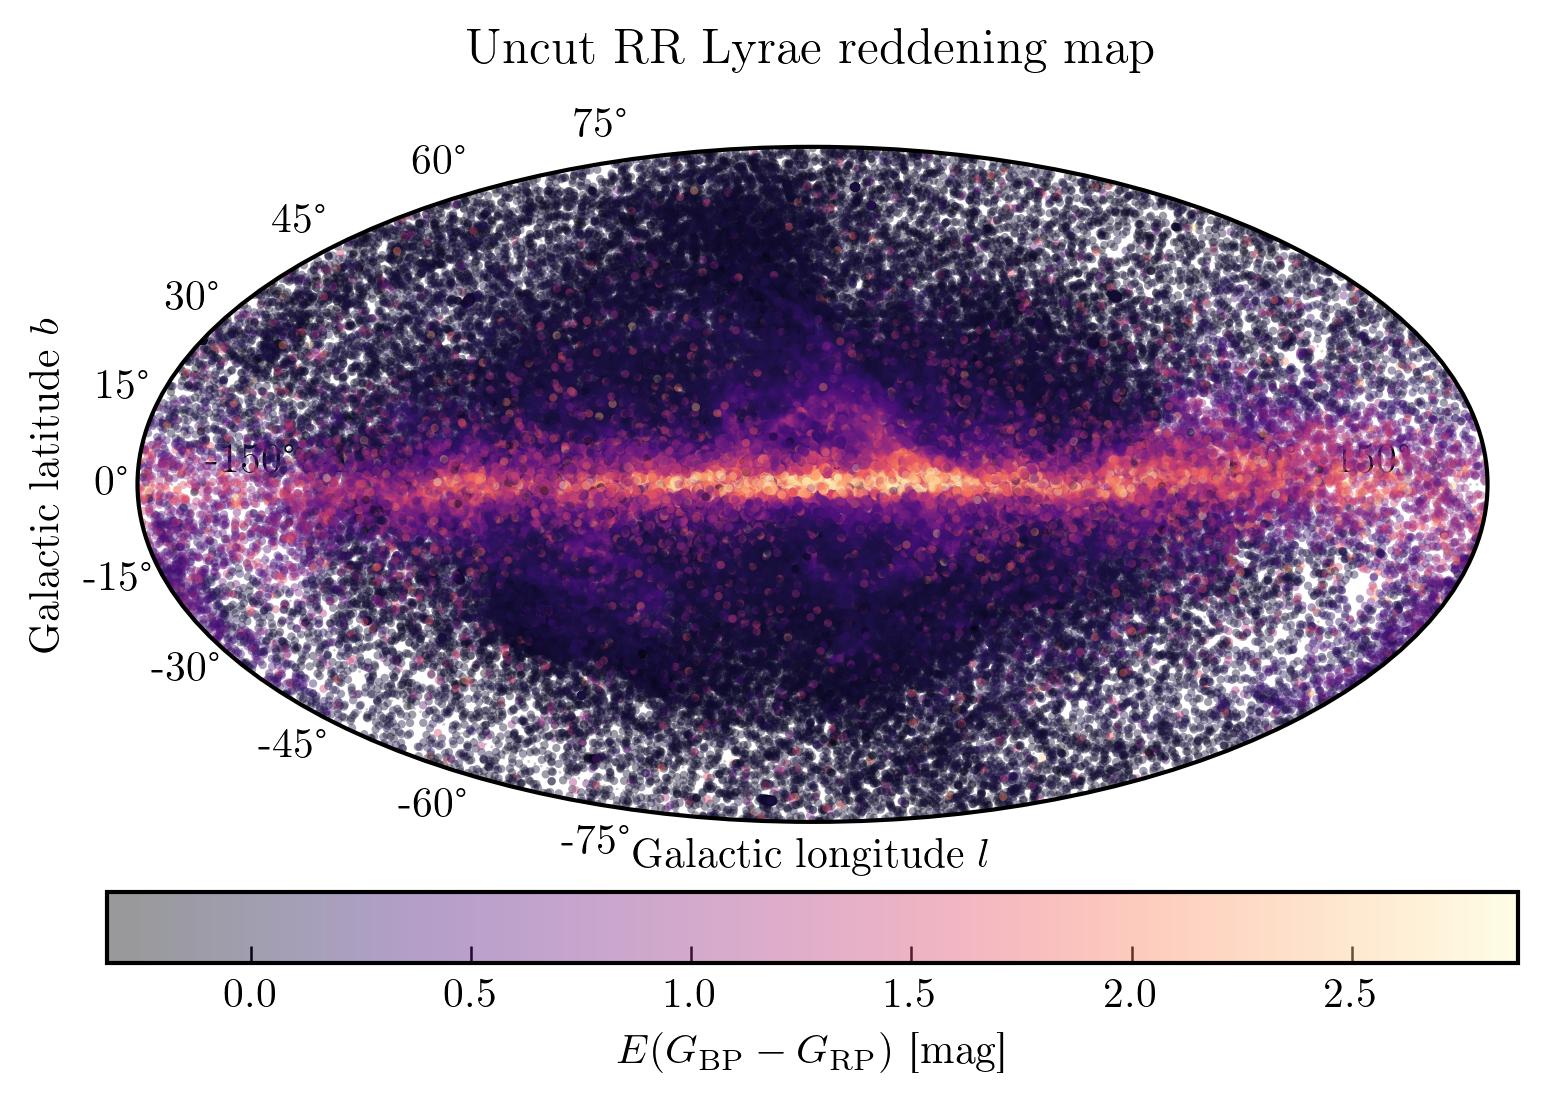

In [6]:
e_finite = np.array(rrlyrae_extinction["E_bprp"], dtype=float)
finite = components["finite"]
vmin = float(min(0.0, np.nanpercentile(e_finite[finite], 0.5)))
vmax = float(np.nanpercentile(e_finite[finite], 99.5))

fig, ax = plot_aitoff_reddening(
    np.array(rrlyrae_extinction["l"], dtype=float)[finite],
    np.array(rrlyrae_extinction["b"], dtype=float)[finite],
    e_finite[finite],
    vmin=vmin, vmax=vmax,
)
ax.set_title("Uncut RR Lyrae reddening map", pad=20)
plt.show()

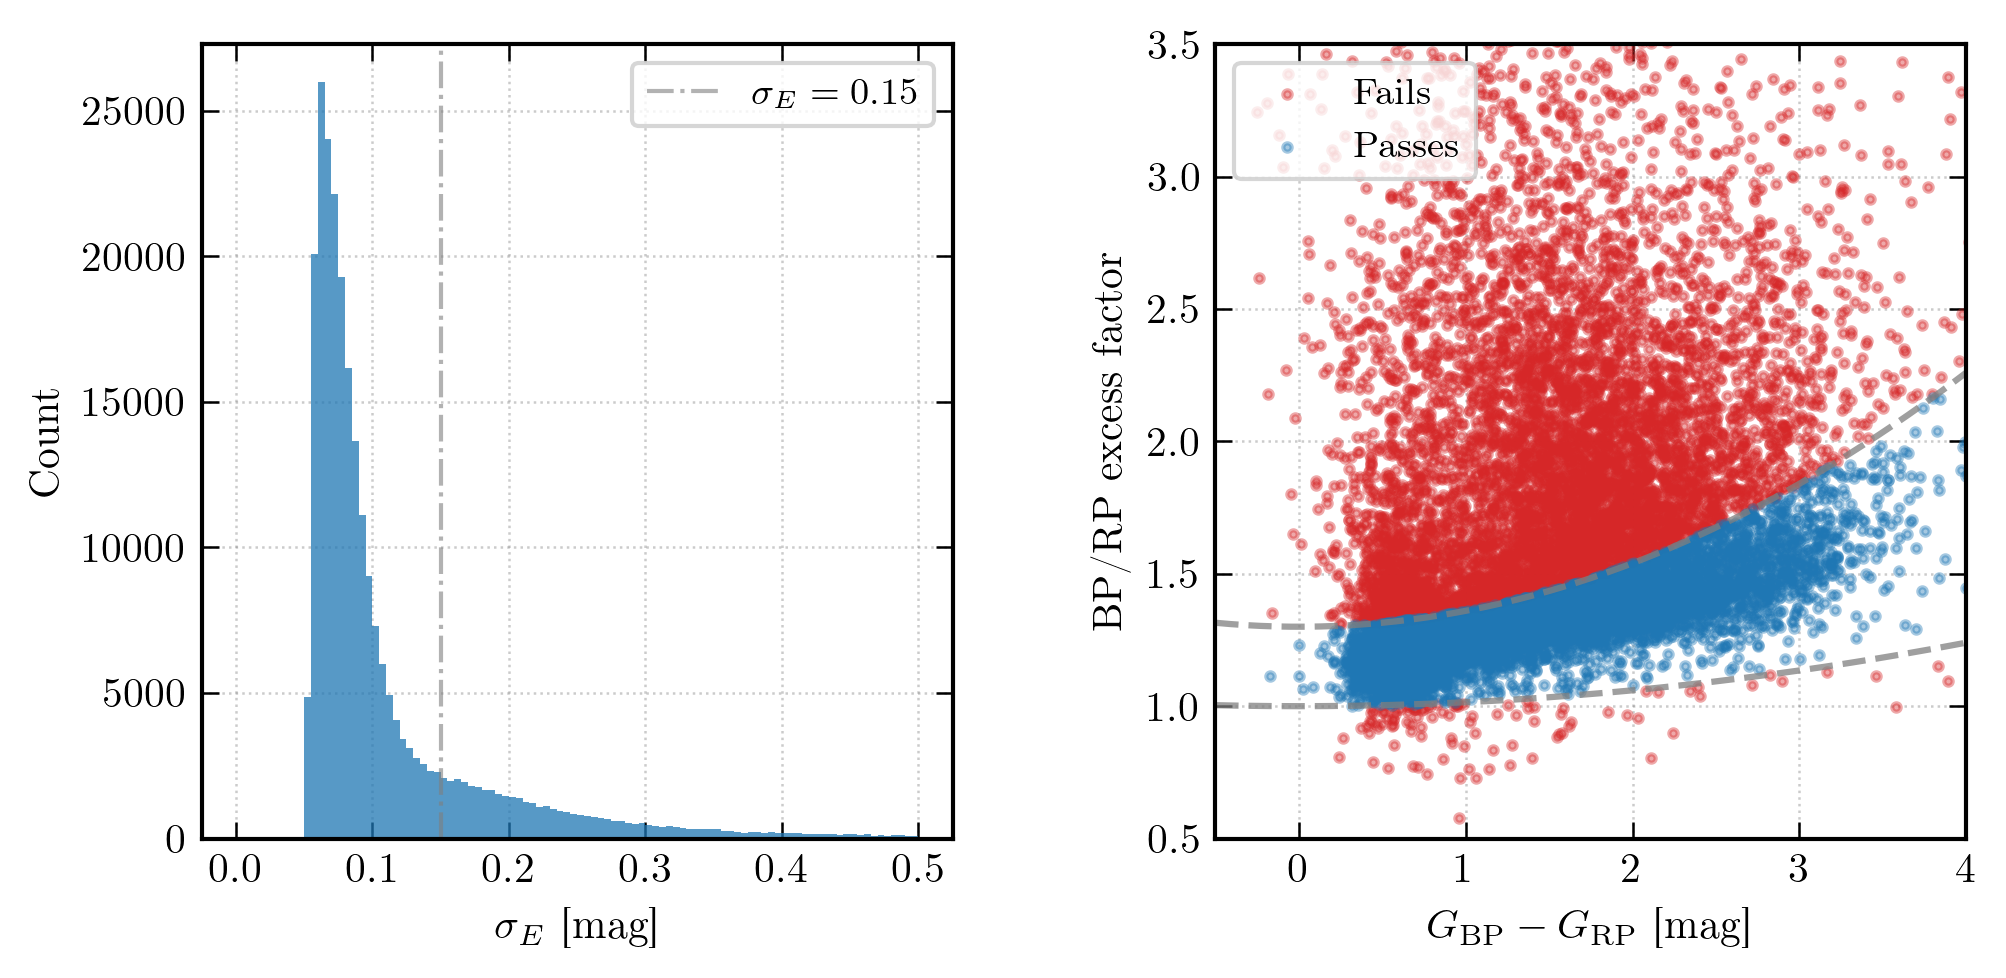

In [7]:
finite = components["finite"]
axes = plot_reddening_quality_diagnostics(
    np.array(rrlyrae_extinction["bp_rp"], dtype=float)[finite],
    np.array(rrlyrae_extinction["phot_bp_rp_excess_factor"], dtype=float)[finite],
    np.array(rrlyrae_extinction["sigma_E"], dtype=float)[finite],
    max_sigma_e=MAX_SIGMA_E,
)
plt.show()

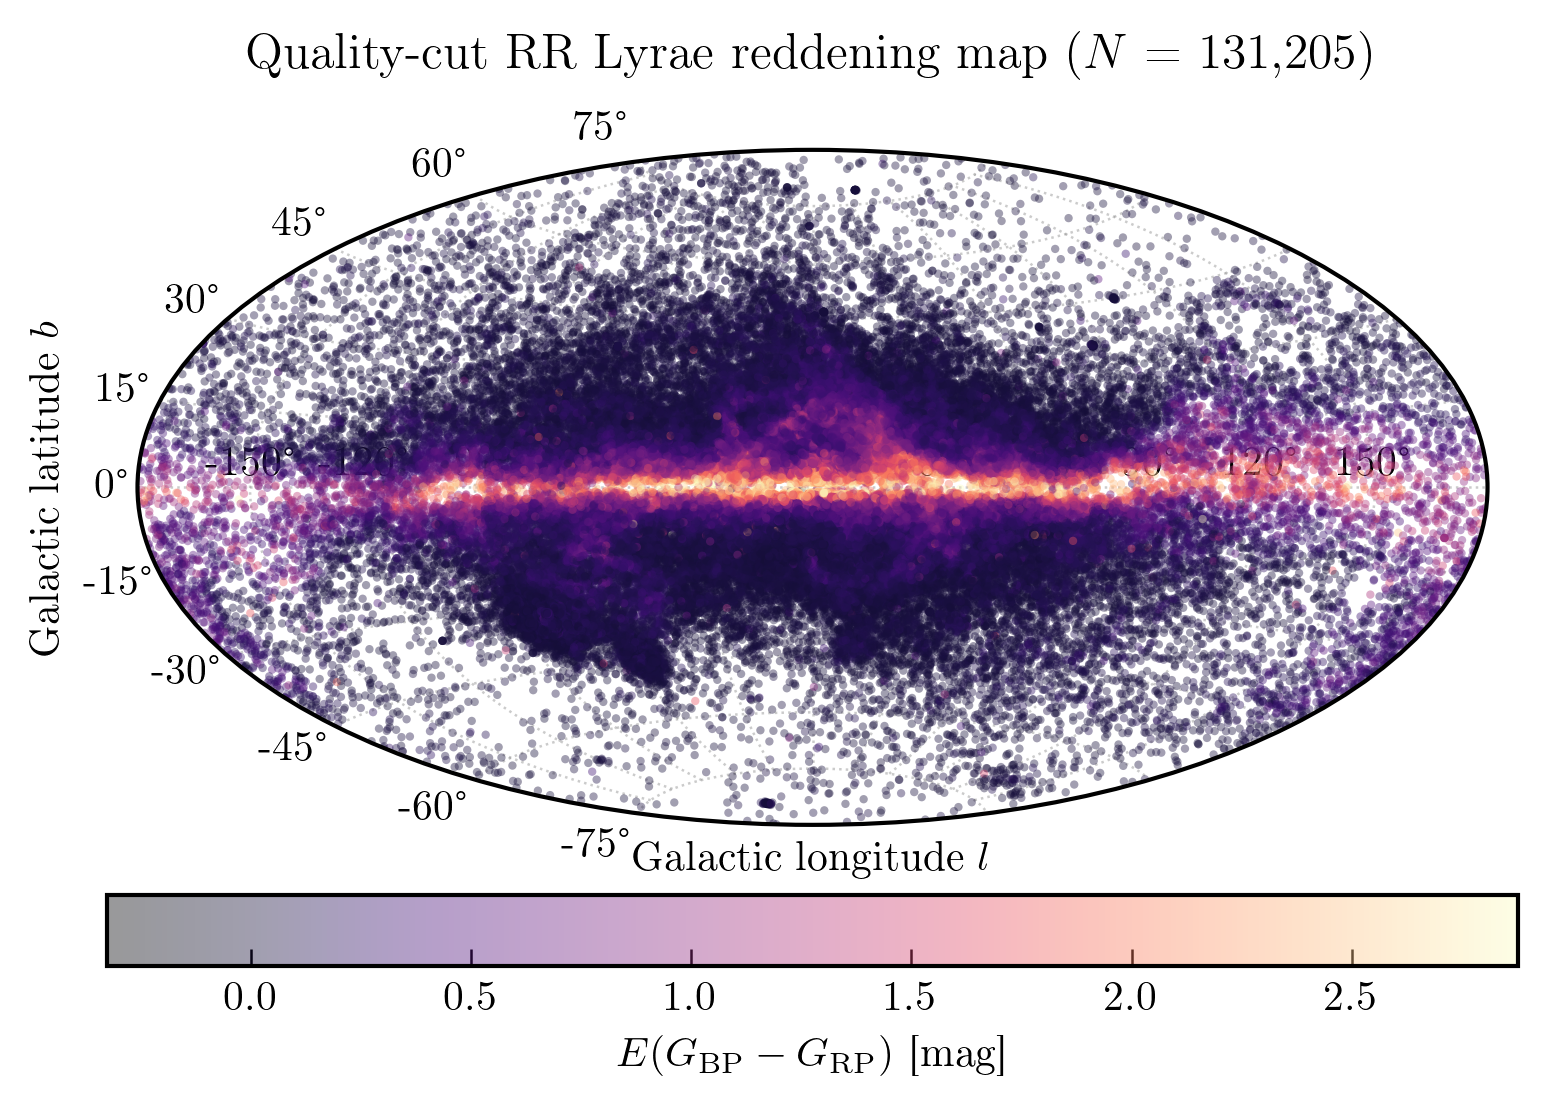

In [8]:
fig, ax = plot_aitoff_reddening(
    np.array(rrlyrae_extinction["l"], dtype=float)[adopted_mask],
    np.array(rrlyrae_extinction["b"], dtype=float)[adopted_mask],
    e_finite[adopted_mask],
    vmin=vmin, vmax=vmax,
)
ax.set_title(f"Quality-cut RR Lyrae reddening map ($N$ = {adopted_mask.sum():,})", pad=20)
plt.show()

In [9]:
from dustmaps.config import config as dustmaps_config
import dustmaps.sfd
from dustmaps.sfd import SFDQuery
from astropy.coordinates import SkyCoord
import astropy.units as u

DUSTMAPS_DATA_DIR = Path(".dustmaps-data")
DUSTMAPS_DATA_DIR.mkdir(parents=True, exist_ok=True)
dustmaps_config["data_dir"] = str(DUSTMAPS_DATA_DIR.resolve())

try:
    sfd = SFDQuery()
except FileNotFoundError:
    dustmaps.sfd.fetch()
    sfd = SFDQuery()

rrlyrae_clean = rrlyrae_extinction[adopted_mask].copy()
coords = SkyCoord(
    l=np.array(rrlyrae_clean["l"], dtype=float) * u.deg,
    b=np.array(rrlyrae_clean["b"], dtype=float) * u.deg,
    frame="galactic",
)
rrlyrae_clean["sfd_ebv"] = sfd(coords)

empirical = np.array(rrlyrae_clean["E_bprp"], dtype=float)
sfd_ebv = np.array(rrlyrae_clean["sfd_ebv"], dtype=float)

print(f"Cleaned sample with SFD: {len(rrlyrae_clean):,} stars")
print(f"Median SFD E(B-V):       {np.nanmedian(sfd_ebv):.4f} mag")
print(f"Median empirical E:      {np.nanmedian(empirical):.4f} mag")

The SFD'98 dust map is not in the data directory:

    /Users/junruiting/GitHub/ay-128/labs/01/.dustmaps-data

To change the data directory, call:

    from dustmaps.config import config
    config['data_dir'] = '/path/to/data/directory'

To download the SFD'98 map to the data directory, call:

    import dustmaps.sfd
    dustmaps.sfd.fetch()



  0.0 B of 64.0 MiB |   0.0 s/B |                       |   0% | ETA:  --:--:--

 70.0 KiB of 64.0 MiB | 557.5 KiB/s |                   |   0% | ETA:   0:01:57

358.0 KiB of 64.0 MiB |   1.4 MiB/s |                   |   0% | ETA:   0:00:46

830.0 KiB of 64.0 MiB |   1.4 MiB/s |                   |   1% | ETA:   0:00:46

...

 60.8 MiB of 64.0 MiB |  11.0 MiB/s |################## |  94% | ETA:   0:00:00

 62.3 MiB of 64.0 MiB |  11.1 MiB/s |################## |  97% | ETA:   0:00:00

 63.2 MiB of 64.0 MiB |  11.1 MiB/s |################## |  98% | ETA:   0:00:00

 64.0 MiB of 64.0 MiB |  11.2 MiB/s |###################| 100% | ETA:  00:00:00

Cleaned sample with SFD: 131,205 stars
Median SFD E(B-V):       0.2616 mag
Median empirical E:      0.2546 mag


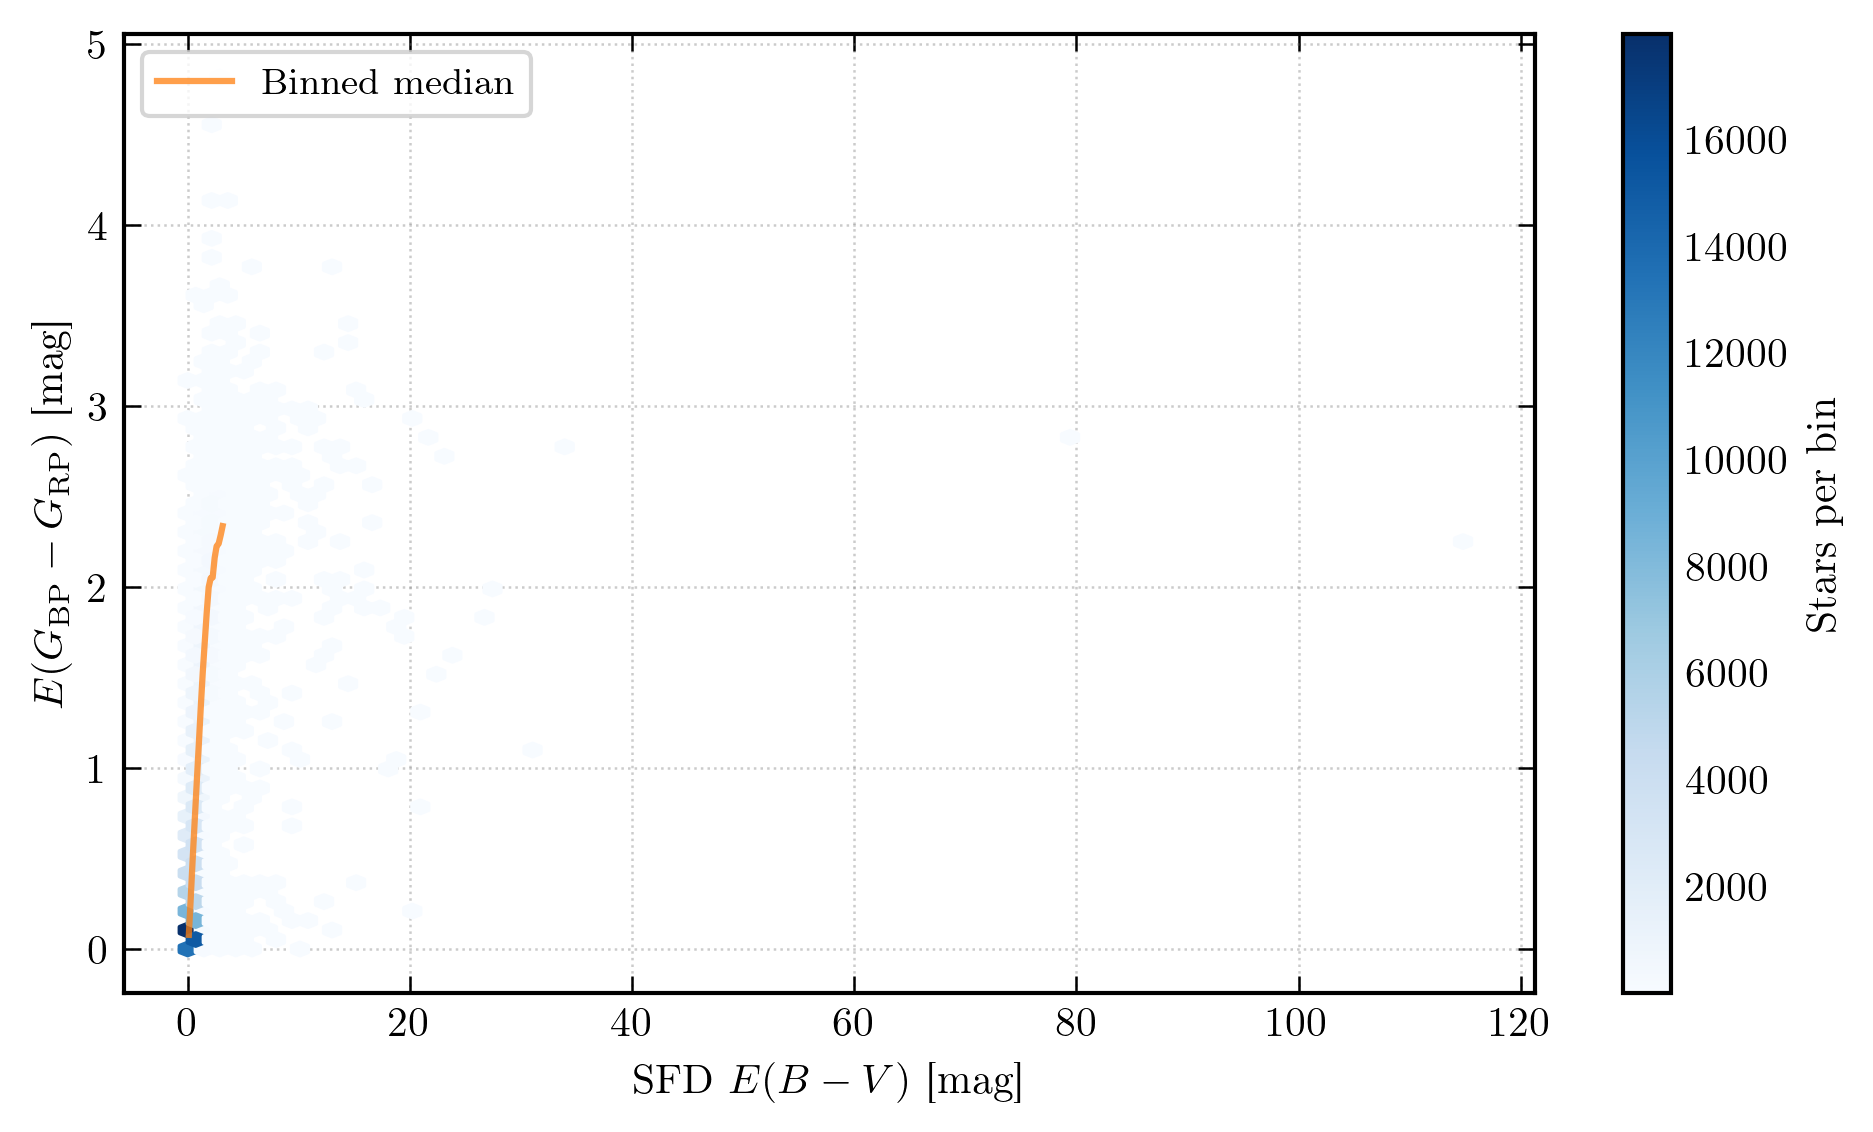

In [10]:
fig, ax = plot_sfd_comparison(sfd_ebv, empirical)
plt.show()

Similar-scale: 128,147 stars, slope=1.111, R²=0.877
Large-SFD:     77 stars


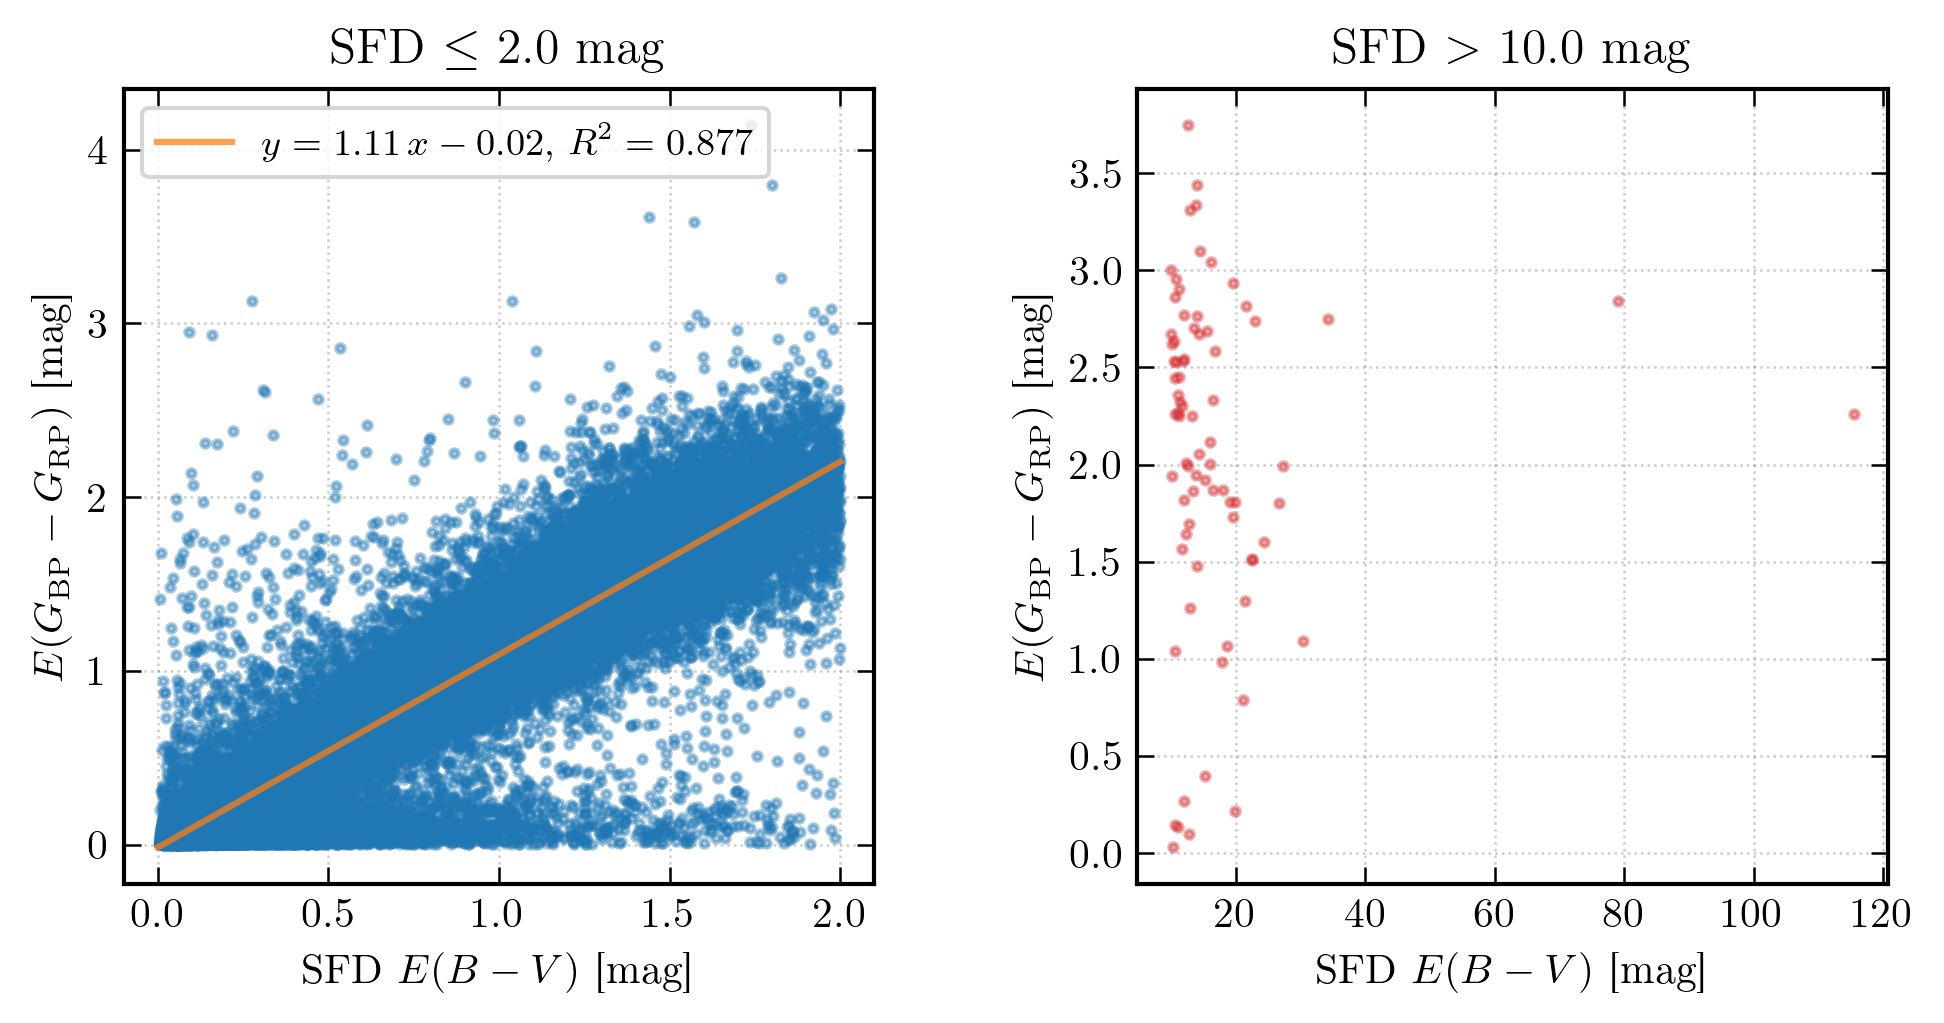

In [11]:
SIMILAR_SCALE_MAX = 2.0
LARGE_SFD_MIN = 10.0

finite_mask = np.isfinite(sfd_ebv) & np.isfinite(empirical)
similar_mask = finite_mask & (sfd_ebv <= SIMILAR_SCALE_MAX)
large_mask = finite_mask & (sfd_ebv > LARGE_SFD_MIN)

x_sim = sfd_ebv[similar_mask]
y_sim = empirical[similar_mask]
slope, intercept = np.polyfit(x_sim, y_sim, 1)
r_sim, _ = pearsonr(x_sim, y_sim)

print(f"Similar-scale: {similar_mask.sum():,} stars, slope={slope:.3f}, R²={r_sim**2:.3f}")
print(f"Large-SFD:     {large_mask.sum():,} stars")

axes = plot_sfd_regime_decomposition(
    sfd_ebv, empirical, similar_mask, large_mask,
    slope, intercept, r_sim**2,
    similar_scale_max=SIMILAR_SCALE_MAX, large_sfd_min=LARGE_SFD_MIN,
)
plt.show()